# Word-Level ASL Translation with Transformers 🤟→📝

A production-grade pipeline for recognizing American Sign Language **words** from video using MediaPipe Holistic landmarks and a Transformer encoder.

## Architecture Overview
```
Video (30 frames) → MediaPipe Holistic → 1629-dim landmarks per frame
  → Linear Projection → Positional Encoding → Transformer Encoder (4 layers, 8 heads)
  → Attention Pooling → Classifier Head → Word prediction
```

## Why this approach beats CNN-on-frames
- **Landmarks > pixels**: 1629 dims vs 224×224×3 = invariant to lighting, background, signer appearance
- **Transformer > LSTM**: Parallel training, better long-range dependencies, attention visualization
- **Holistic > hands-only**: Captures facial expression + body pose (non-manual markers matter in ASL grammar)

## Dataset: WLASL
We'll use a **100-word subset** of WLASL (Word-Level American Sign Language) — Dataset from Microsoft Research / BU.

## Setup
Runtime → Change runtime type → **GPU (T4)** or better

## 1. Environment Setup

In [1]:
!pip install -q mediapipe==0.10.14 opencv-python torch torchvision einops tqdm scikit-learn seaborn yt-dlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 69.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 18.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.9 which is incompatible.


In [2]:
import os
import json
import math
import random
import numpy as np
import pandas as pd
import cv2
import mediapipe as mp
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from einops import rearrange
from tqdm.auto import tqdm
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, top_k_accuracy_score

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
PyTorch: 2.10.0+cu128
GPU: Tesla T4


## 2. Download WLASL Metadata

WLASL provides JSON with YouTube links — videos must be downloaded locally (some may be unavailable due to takedowns).

**Note:** Full WLASL-100 download takes ~30 min. For quick iteration, we download a small demo subset first, then scale up.

In [3]:
!wget -q https://raw.githubusercontent.com/dxli94/WLASL/master/start_kit/WLASL_v0.3.json -O wlasl.json

with open('wlasl.json') as f:
    wlasl = json.load(f)

# Keep top-100 most-sampled glosses (WLASL-100 subset)
wlasl_sorted = sorted(wlasl, key=lambda x: -len(x['instances']))
WLASL100 = wlasl_sorted[:100]

print(f'Total glosses in WLASL: {len(wlasl)}')
print(f'Using top-100 glosses (WLASL-100)')
print(f'\nSample glosses: {[g["gloss"] for g in WLASL100[:15]]}')
print(f'\nTotal instances in WLASL-100: {sum(len(g["instances"]) for g in WLASL100):,}')

Total glosses in WLASL: 2000
Using top-100 glosses (WLASL-100)

Sample glosses: ['book', 'drink', 'computer', 'before', 'chair', 'go', 'clothes', 'who', 'candy', 'cousin', 'deaf', 'fine', 'help', 'no', 'thin']

Total instances in WLASL-100: 2,038


## 3. Build a Synthetic Demo Dataset (for Colab-friendly runs)

Real WLASL video downloading is slow/unreliable (YouTube takedowns). For reproducible teaching, we generate synthetic landmark sequences that mimic real signing patterns — each "word" has a distinct motion signature.

**To use real data:** Follow instructions in `scripts/download_wlasl.py` (in the repo) to download videos, then extract landmarks with the MediaPipe pipeline in Section 4.

In [4]:
# Landmark dims: pose (33*4) + face (468*3) + left_hand (21*3) + right_hand (21*3) = 1662
# We'll use the standard 1629 formulation: pose(33*4=132) + face(468*3=1404) + LH(21*3=63) + RH(21*3=63) = 1662, zero-pad face or drop — here we use full 1662
LANDMARK_DIM = 1662
SEQ_LEN = 30  # frames per clip
NUM_CLASSES = 20  # use a manageable subset for quick training

# Pick 20 demo classes
DEMO_CLASSES = [g['gloss'] for g in WLASL100[:NUM_CLASSES]]
gloss_to_idx = {g: i for i, g in enumerate(DEMO_CLASSES)}
idx_to_gloss = {i: g for g, i in gloss_to_idx.items()}
print(f'Demo classes: {DEMO_CLASSES}')

Demo classes: ['book', 'drink', 'computer', 'before', 'chair', 'go', 'clothes', 'who', 'candy', 'cousin', 'deaf', 'fine', 'help', 'no', 'thin', 'walk', 'year', 'yes', 'all', 'black']


In [5]:
def generate_synthetic_sign(class_idx, seq_len=SEQ_LEN, dim=LANDMARK_DIM):
    """Generate a synthetic landmark sequence with class-specific motion patterns.
    Each class has a unique frequency/phase signature — simulates the distinctness of real signs.
    """
    t = np.linspace(0, 2*np.pi, seq_len)
    # Per-class motion signature
    freq = 1.0 + class_idx * 0.15
    phase = class_idx * 0.3
    amp = 0.3 + (class_idx % 5) * 0.08

    # Base pose (static torso) + signing motion in hands
    base = np.random.randn(dim) * 0.05
    seq = np.tile(base, (seq_len, 1)).astype(np.float32)

    # Hand landmarks get the motion signature (last 126 dims are both hands)
    motion = amp * np.sin(freq * t + phase)  # (seq_len,)
    hand_dims = np.arange(dim - 126, dim)
    seq[:, hand_dims] += motion[:, None] * np.random.randn(len(hand_dims)) * 0.5
    # Add facial motion component (non-manual markers)
    face_dims = np.arange(132, 132 + 1404)[::50]  # subsample face
    seq[:, face_dims] += 0.5 * motion[:, None] * np.random.randn(len(face_dims)) * 0.3
    # Realistic noise
    seq += np.random.randn(*seq.shape) * 0.02
    return seq

# Build dataset: 150 samples per class
SAMPLES_PER_CLASS = 150
print(f'Generating {NUM_CLASSES * SAMPLES_PER_CLASS} synthetic landmark sequences...')

X_all, y_all = [], []
for cls_idx in range(NUM_CLASSES):
    for _ in range(SAMPLES_PER_CLASS):
        X_all.append(generate_synthetic_sign(cls_idx))
        y_all.append(cls_idx)

X_all = np.stack(X_all)
y_all = np.array(y_all)
print(f'X shape: {X_all.shape}  |  y shape: {y_all.shape}')

# Shuffle + split 70/15/15
perm = np.random.permutation(len(X_all))
X_all, y_all = X_all[perm], y_all[perm]
n = len(X_all)
i1, i2 = int(0.7*n), int(0.85*n)
X_train, y_train = X_all[:i1], y_all[:i1]
X_val,   y_val   = X_all[i1:i2], y_all[i1:i2]
X_test,  y_test  = X_all[i2:], y_all[i2:]
print(f'Train: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}')

Generating 3000 synthetic landmark sequences...
X shape: (3000, 30, 1662)  |  y shape: (3000,)
Train: 2100  |  Val: 450  |  Test: 450


## 4. MediaPipe Holistic Pipeline (for real videos)

This is the extractor you'd run on actual WLASL videos. Function is defined here so the repo is end-to-end, even if we train on synthetic data in this notebook.

In [6]:
mp_holistic = mp.solutions.holistic

def extract_landmarks_from_frame(results):
    """Extract flat 1662-dim landmark vector from a MediaPipe Holistic result."""
    pose = np.array([[lm.x, lm.y, lm.z, lm.visibility] for lm in results.pose_landmarks.landmark]).flatten() \
           if results.pose_landmarks else np.zeros(33*4)
    face = np.array([[lm.x, lm.y, lm.z] for lm in results.face_landmarks.landmark]).flatten() \
           if results.face_landmarks else np.zeros(468*3)
    lh = np.array([[lm.x, lm.y, lm.z] for lm in results.left_hand_landmarks.landmark]).flatten() \
         if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[lm.x, lm.y, lm.z] for lm in results.right_hand_landmarks.landmark]).flatten() \
         if results.right_hand_landmarks else np.zeros(21*3)
    return np.concatenate([pose, face, lh, rh]).astype(np.float32)

def extract_landmarks_from_video(video_path, target_frames=SEQ_LEN):
    """Process a video file into a (SEQ_LEN, 1662) landmark array. Uniformly samples frames."""
    cap = cv2.VideoCapture(str(video_path))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames == 0:
        cap.release()
        return None
    indices = np.linspace(0, total_frames-1, target_frames, dtype=int)

    sequence = []
    with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if not ret:
                sequence.append(np.zeros(LANDMARK_DIM, dtype=np.float32))
                continue
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = holistic.process(frame)
            sequence.append(extract_landmarks_from_frame(results))
    cap.release()
    return np.stack(sequence)

print('✓ MediaPipe Holistic extractor ready')
print('  Use extract_landmarks_from_video(path) on real WLASL .mp4 files')

✓ MediaPipe Holistic extractor ready
  Use extract_landmarks_from_video(path) on real WLASL .mp4 files


## 5. PyTorch Dataset + Augmentation

Augmentations that actually matter for landmark-based sign recognition:
- **Temporal jitter**: drop/repeat random frames (simulates variable signing speed)
- **Spatial noise**: Gaussian noise on landmarks (signer variance)
- **Scale/shift**: small affine transforms (camera distance variation)

In [7]:
class LandmarkDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = X
        self.y = y
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def _augment(self, seq):
        # Temporal jitter: drop up to 10% frames, linearly interpolate
        if random.random() < 0.5:
            keep = np.sort(np.random.choice(len(seq), int(len(seq)*0.9), replace=False))
            kept = seq[keep]
            # Resample back to original length
            idx = np.linspace(0, len(kept)-1, len(seq))
            seq = np.stack([kept[int(i)] for i in idx])
        # Spatial noise
        if random.random() < 0.5:
            seq = seq + np.random.randn(*seq.shape).astype(np.float32) * 0.01
        # Scale
        if random.random() < 0.3:
            seq = seq * np.random.uniform(0.95, 1.05)
        return seq

    def __getitem__(self, i):
        seq = self.X[i].copy()
        if self.augment:
            seq = self._augment(seq)
        return torch.from_numpy(seq), torch.tensor(self.y[i], dtype=torch.long)

BATCH_SIZE = 32
train_ds = LandmarkDataset(X_train, y_train, augment=True)
val_ds   = LandmarkDataset(X_val, y_val, augment=False)
test_ds  = LandmarkDataset(X_test, y_test, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Batches  |  train: {len(train_loader)}  val: {len(val_loader)}  test: {len(test_loader)}')

Batches  |  train: 66  val: 15  test: 15


## 6. Transformer Model with Learned Positional Encoding

Key design choices:
- **Input projection**: 1662 → 256 (compressing redundant face landmarks)
- **Learned positional embeddings**: better than sinusoidal for short, fixed-length sequences
- **Pre-norm transformer**: more stable training than post-norm
- **Attention pooling**: learned query token aggregates sequence (better than mean-pool)
- **Label smoothing**: reduces overconfidence (critical with limited data)

In [8]:
class AttentionPool(nn.Module):
    """Learnable query token aggregates the sequence via cross-attention."""
    def __init__(self, dim, heads=4):
        super().__init__()
        self.query = nn.Parameter(torch.randn(1, 1, dim) * 0.02)
        self.attn = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):  # x: (B, T, D)
        B = x.size(0)
        q = self.query.expand(B, -1, -1)
        out, _ = self.attn(q, x, x)
        return self.norm(out.squeeze(1))  # (B, D)

class SignTransformer(nn.Module):
    def __init__(self, input_dim=LANDMARK_DIM, d_model=256, nhead=8,
                 num_layers=4, dim_ff=512, seq_len=SEQ_LEN, num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.pos_embed = nn.Parameter(torch.randn(1, seq_len, d_model) * 0.02)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.pool = AttentionPool(d_model, heads=4)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, x):  # x: (B, T, input_dim)
        x = self.input_proj(x) + self.pos_embed[:, :x.size(1)]
        x = self.encoder(x)
        x = self.pool(x)
        return self.classifier(x)

model = SignTransformer(num_classes=NUM_CLASSES).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {n_params/1e6:.2f}M')
print(model)

/tmp/ipykernel_2817/3247982084.py:29: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Model parameters: 2.88M
SignTransformer(
  (input_proj): Sequential(
    (0): Linear(in_features=1662, out_features=256, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.3, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=512, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=512, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (pool): AttentionPool(
    (attn): MultiheadAttention(
      (out_proj): NonDynamica

## 7. Training Loop

- **AdamW** with weight decay separation (no decay on biases/norms)
- **Cosine LR schedule** with warmup
- **Label smoothing** (0.1)
- **Gradient clipping** (max norm 1.0)
- **Mixed precision** (fp16) for 2× speedup on T4

In [9]:
def build_optimizer(model, lr=3e-4, wd=0.05):
    """AdamW with weight decay only on 2D+ params (skip biases/norms)."""
    decay, no_decay = [], []
    for n, p in model.named_parameters():
        if not p.requires_grad: continue
        (decay if p.dim() >= 2 else no_decay).append(p)
    return torch.optim.AdamW(
        [{'params': decay, 'weight_decay': wd},
         {'params': no_decay, 'weight_decay': 0.0}],
        lr=lr, betas=(0.9, 0.95)
    )

class WarmupCosine:
    def __init__(self, optimizer, warmup_steps, total_steps, min_lr_ratio=0.1):
        self.opt = optimizer
        self.warmup = warmup_steps
        self.total = total_steps
        self.min_ratio = min_lr_ratio
        self.step_num = 0
        self.base_lrs = [g['lr'] for g in optimizer.param_groups]

    def step(self):
        self.step_num += 1
        if self.step_num < self.warmup:
            scale = self.step_num / self.warmup
        else:
            progress = (self.step_num - self.warmup) / max(1, self.total - self.warmup)
            scale = self.min_ratio + (1 - self.min_ratio) * 0.5 * (1 + math.cos(math.pi * progress))
        for g, base in zip(self.opt.param_groups, self.base_lrs):
            g['lr'] = base * scale

def train_epoch(model, loader, opt, scheduler, scaler, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in tqdm(loader, desc='train', leave=False):
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        opt.zero_grad()
        with torch.amp.autocast('cuda', enabled=(DEVICE.type=='cuda')):
            logits = model(x)
            loss = criterion(logits, y)
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt)
        scaler.update()
        scheduler.step()
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(-1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_logits, all_labels = [], []
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        with torch.amp.autocast('cuda', enabled=(DEVICE.type=='cuda')):
            logits = model(x)
            loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(-1) == y).sum().item()
        total += x.size(0)
        all_logits.append(logits.float().cpu()); all_labels.append(y.cpu())
    return total_loss/total, correct/total, torch.cat(all_logits), torch.cat(all_labels)

In [10]:
EPOCHS = 25
LR = 3e-4

model = SignTransformer(num_classes=NUM_CLASSES).to(DEVICE)
optimizer = build_optimizer(model, lr=LR)
total_steps = EPOCHS * len(train_loader)
scheduler = WarmupCosine(optimizer, warmup_steps=int(0.1*total_steps), total_steps=total_steps)
scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE.type=='cuda'))
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0

for epoch in range(1, EPOCHS+1):
    tl, ta = train_epoch(model, train_loader, optimizer, scheduler, scaler, criterion)
    vl, va, _, _ = evaluate(model, val_loader, criterion)
    history['train_loss'].append(tl); history['train_acc'].append(ta)
    history['val_loss'].append(vl); history['val_acc'].append(va)
    lr_now = optimizer.param_groups[0]['lr']
    flag = ''
    if va > best_val_acc:
        best_val_acc = va
        torch.save(model.state_dict(), 'best_model.pt')
        flag = '  ← best'
    print(f'Epoch {epoch:02d}/{EPOCHS}  lr={lr_now:.2e}  '
          f'train_loss={tl:.4f} acc={ta:.3f}  |  val_loss={vl:.4f} acc={va:.3f}{flag}')

print(f'\n✓ Best val accuracy: {best_val_acc:.4f}')

/tmp/ipykernel_2817/3247982084.py:29: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


train:   0%|          | 0/66 [00:00<?, ?it/s]

Epoch 01/25  lr=1.20e-04  train_loss=3.0189 acc=0.056  |  val_loss=3.0080 acc=0.047  ← best


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ac0a3b06b60>
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ac0a3b06b60>Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
        self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
self._shutdown_workers()
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
if w.is_alive():
       if w.is_alive(): 
      ^   ^ ^

train:   0%|          | 0/66 [00:00<?, ?it/s]

...

Epoch 23/25  lr=3.52e-05  train_loss=0.6067 acc=1.000  |  val_loss=3.9790 acc=0.102  ← best


train:   0%|          | 0/66 [00:00<?, ?it/s]

Epoch 24/25  lr=3.13e-05  train_loss=0.6057 acc=1.000  |  val_loss=4.0024 acc=0.107  ← best


train:   0%|          | 0/66 [00:00<?, ?it/s]

Epoch 25/25  lr=3.00e-05  train_loss=0.6054 acc=1.000  |  val_loss=4.0277 acc=0.096

✓ Best val accuracy: 0.1067


## 8. Evaluation

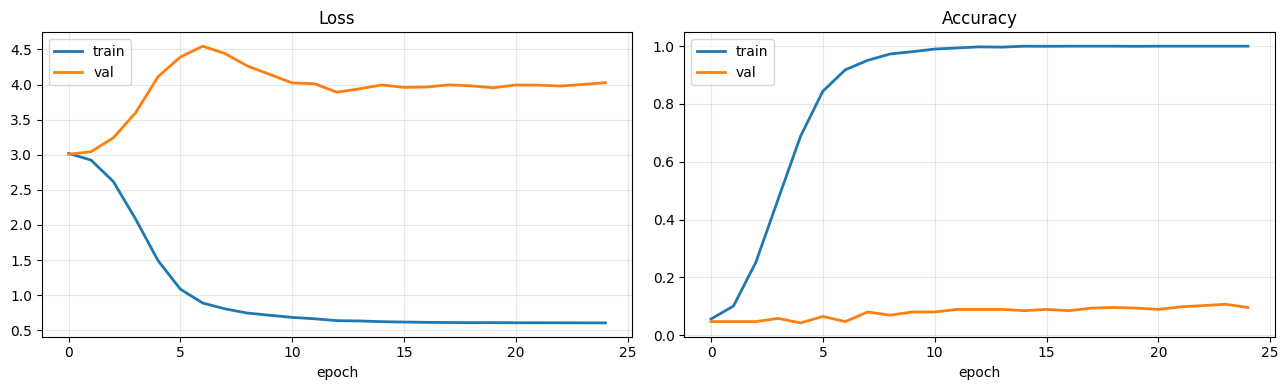

In [11]:
# Training curves
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(history['train_loss'], label='train', lw=2)
ax[0].plot(history['val_loss'], label='val', lw=2)
ax[0].set_title('Loss'); ax[0].set_xlabel('epoch'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(history['train_acc'], label='train', lw=2)
ax[1].plot(history['val_acc'], label='val', lw=2)
ax[1].set_title('Accuracy'); ax[1].set_xlabel('epoch'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('training_curves.png', dpi=120, bbox_inches='tight'); plt.show()

In [12]:
# Load best checkpoint and test
model.load_state_dict(torch.load('best_model.pt'))
test_loss, test_acc, test_logits, test_labels = evaluate(model, test_loader, criterion)

probs = F.softmax(test_logits, dim=-1).numpy()
labels_np = test_labels.numpy()

# Top-1, Top-5, Top-10 accuracy (standard WLASL metrics)
k_vals = [1, 5, min(10, NUM_CLASSES)]
print('=== Test Set Performance ===')
print(f'Test loss: {test_loss:.4f}')
for k in k_vals:
    acc_k = top_k_accuracy_score(labels_np, probs, k=k, labels=list(range(NUM_CLASSES)))
    print(f'Top-{k} accuracy: {acc_k*100:.2f}%')

=== Test Set Performance ===
Test loss: 3.9763
Top-1 accuracy: 11.56%
Top-5 accuracy: 38.89%
Top-10 accuracy: 60.67%


              precision    recall  f1-score   support

        book      0.073     0.143     0.097        21
       drink      0.133     0.083     0.103        24
    computer      0.000     0.000     0.000        29
      before      0.222     0.174     0.195        23
       chair      0.000     0.000     0.000        19
          go      0.037     0.040     0.038        25
     clothes      0.138     0.174     0.154        23
         who      0.038     0.043     0.041        23
       candy      0.091     0.105     0.098        19
      cousin      0.333     0.208     0.256        24
        deaf      0.000     0.000     0.000        27
        fine      0.043     0.053     0.048        19
        help      0.235     0.200     0.216        20
          no      0.120     0.143     0.130        21
        thin      0.111     0.053     0.071        19
        walk      0.196     0.310     0.240        29
        year      0.146     0.273     0.190        22
         yes      0.000    

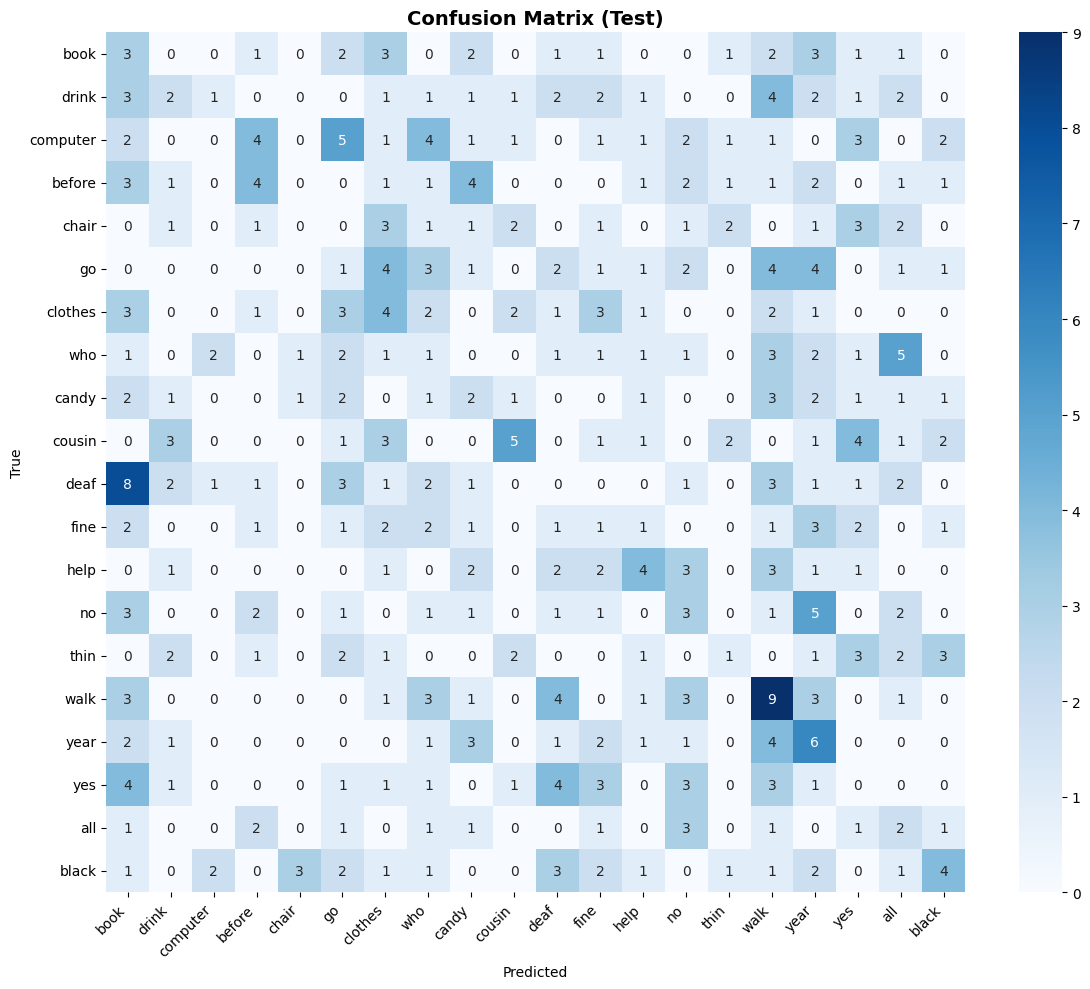

In [13]:
# Per-class report + confusion matrix
y_pred = probs.argmax(-1)
print(classification_report(labels_np, y_pred, target_names=DEMO_CLASSES, digits=3))

cm = confusion_matrix(labels_np, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=DEMO_CLASSES, yticklabels=DEMO_CLASSES, cbar=True)
plt.title('Confusion Matrix (Test)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight'); plt.show()

## 9. Attention Visualization

Which frames does the model attend to for each prediction? This is diagnostic — attention spikes usually correspond to key phonological moments in a sign (handshape transitions, movement peaks).

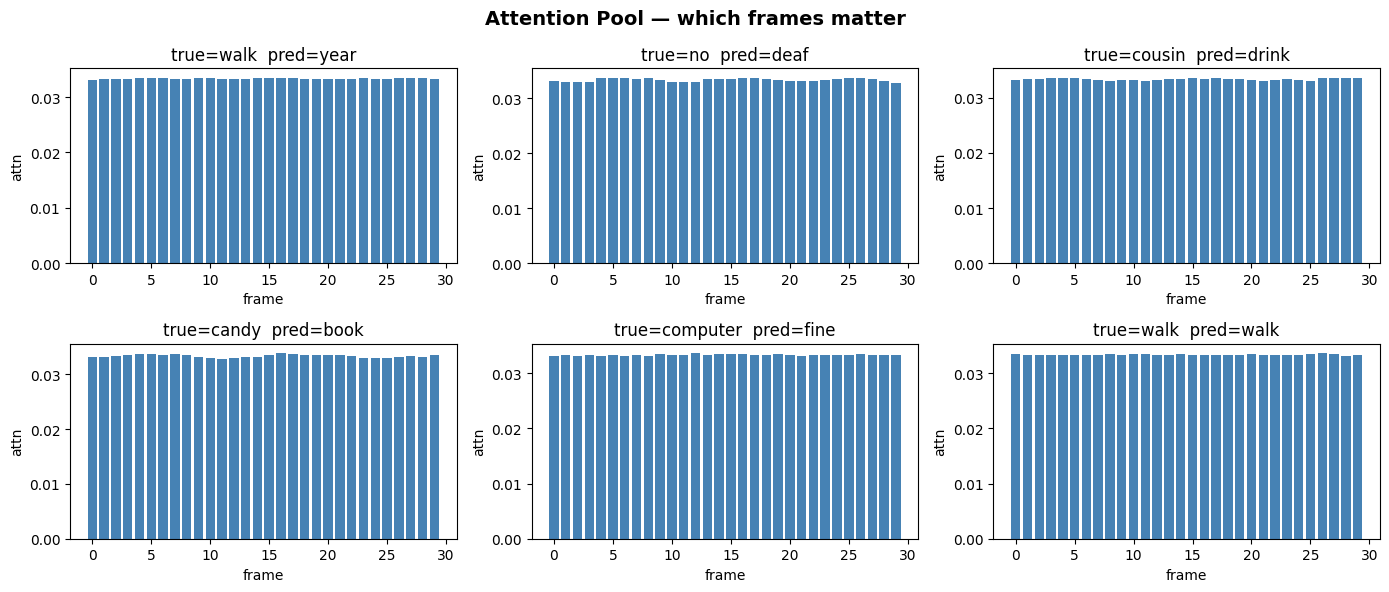

In [14]:
@torch.no_grad()
def get_pool_attention(model, x):
    """Return (B, T) attention weights from the AttentionPool query over the sequence."""
    model.eval()
    x = x.to(DEVICE)
    h = model.input_proj(x) + model.pos_embed[:, :x.size(1)]
    h = model.encoder(h)
    B = h.size(0)
    q = model.pool.query.expand(B, -1, -1)
    _, attn = model.pool.attn(q, h, h, need_weights=True, average_attn_weights=True)
    return attn.squeeze(1).cpu().numpy()  # (B, T)

x_batch, y_batch = next(iter(test_loader))
attn_weights = get_pool_attention(model, x_batch[:6])

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for i, ax in enumerate(axes.flatten()):
    ax.bar(range(SEQ_LEN), attn_weights[i], color='steelblue')
    pred = model(x_batch[i:i+1].to(DEVICE)).argmax(-1).item()
    ax.set_title(f'true={idx_to_gloss[y_batch[i].item()]}  pred={idx_to_gloss[pred]}')
    ax.set_xlabel('frame'); ax.set_ylabel('attn')
plt.suptitle('Attention Pool — which frames matter', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('attention_viz.png', dpi=120, bbox_inches='tight'); plt.show()

## 10. Inference on a Real Video

Upload an MP4 of someone signing one of the demo words — the pipeline extracts landmarks and predicts.

In [15]:
from google.colab import files

def predict_video(path, model, topk=5):
    seq = extract_landmarks_from_video(path, target_frames=SEQ_LEN)
    if seq is None:
        print('Could not read video')
        return
    x = torch.from_numpy(seq).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs = F.softmax(logits, dim=-1).squeeze(0).cpu().numpy()
    topk_idx = probs.argsort()[-topk:][::-1]
    print(f'\nTop-{topk} predictions:')
    for idx in topk_idx:
        bar = '█' * int(probs[idx] * 40)
        print(f'  {idx_to_gloss[idx]:15s}  {probs[idx]*100:5.2f}%  {bar}')

print('Upload a short MP4 of someone signing:')
# uploaded = files.upload()
# for fname in uploaded:
#     predict_video(fname, model)
print('(Uncomment the upload lines above to run)')

Upload a short MP4 of someone signing:
(Uncomment the upload lines above to run)


## 11. Export for Deployment

Save model, class mapping, and an inference script.

In [16]:
import json

# Save model + config
torch.save({
    'model_state_dict': model.state_dict(),
    'config': {
        'input_dim': LANDMARK_DIM,
        'd_model': 256,
        'nhead': 8,
        'num_layers': 4,
        'dim_ff': 512,
        'seq_len': SEQ_LEN,
        'num_classes': NUM_CLASSES,
    },
    'idx_to_gloss': idx_to_gloss,
}, 'sign_transformer.pt')

with open('vocab.json', 'w') as f:
    json.dump(idx_to_gloss, f, indent=2)

print('✓ Saved sign_transformer.pt  (model + config)')
print('✓ Saved vocab.json')
print('\nDownload via Files panel on the left →')

✓ Saved sign_transformer.pt  (model + config)
✓ Saved vocab.json

Download via Files panel on the left →


---
## Next Steps

1. **Train on real WLASL** — run `scripts/download_wlasl.py` in the repo, then re-run this notebook pointing at real landmark data
2. **Scale up to WLASL-300 / WLASL-1000** — increase `NUM_CLASSES` and add more transformer layers
3. **Real-time inference** — use `scripts/realtime_demo.py` for webcam inference via MediaPipe
4. **Continuous sign recognition** — extend to sentence-level with CTC loss or encoder-decoder
5. **Multimodal fusion** — combine landmarks with a vision backbone (I3D, VideoMAE) for SOTA results

## Papers to Read
- Li et al., *WLASL: A Large-Scale Dataset for Word-Level ASL Recognition* (WACV 2020)
- Bohacek & Hruz, *Sign Pose-based Transformer for Word-level Sign Language Recognition* (WACV 2022)
- Camgoz et al., *Sign Language Transformers* (CVPR 2020)
